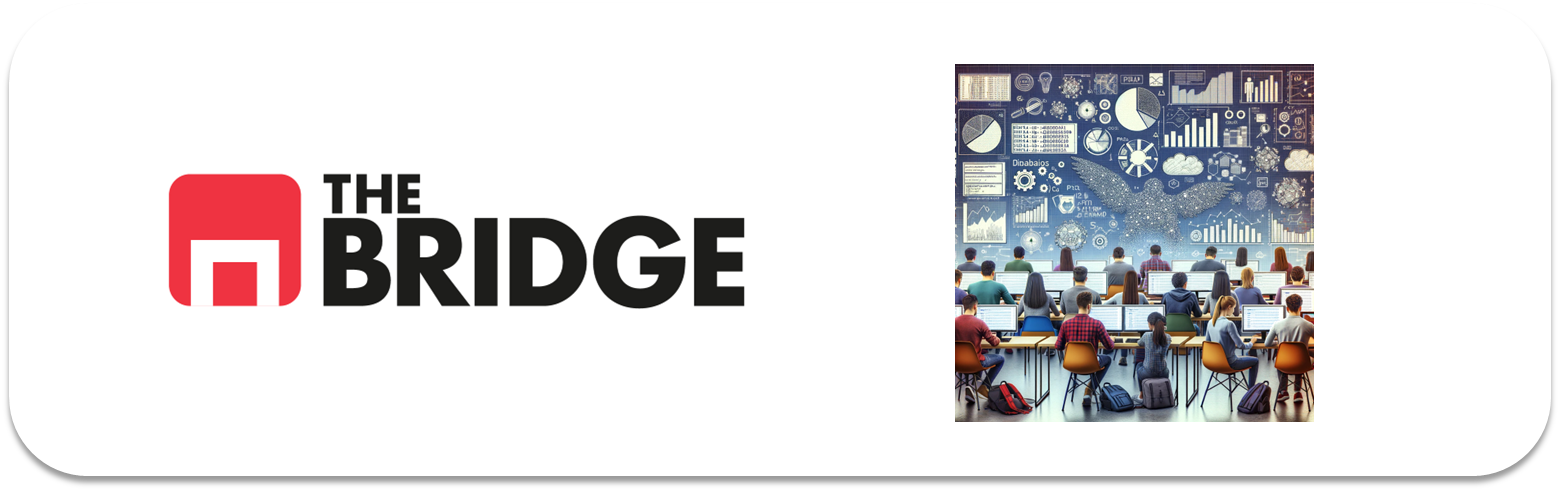

## PRACTICA OBLIGATORIA: **Regresion Lineal y Regularización**

* La práctica obligatoria de esta unidad consiste en hacer un modelado completo de un problema que ya conoces, la predicción de casas, pero con otro dataset. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Modelo de Regresión Lineal

El objetivo del modelo que tienes que construir es predecir la mediana del precio de las casas en una zona del área metropolitana de Boston dadas las características de las mismas. Sí, es parecido pero no igual a lo que hemos venido haciendo.

Aquí tienes una descripción de las variables del dataset, del que tendrás que decidir el target:  

***CRIM:*** Tasa de criminalidad per cápita por ciudad  
***ZN:*** Proporción de terreno residencial destinado a lotes de más de 25,000 pies cuadrados  
***INDUS:*** Proporción de acres de negocios no minoristas por ciudad  
***CHAS:*** Variable ficticia del río Charles (= 1 si el sector limita con el río; 0 en caso contrario)  
***NOX:*** Concentración de óxidos de nitrógeno (partes por 10 millones)  
***RM:*** Número promedio de habitaciones por vivienda  
***AGE:*** Proporción de unidades ocupadas por el propietario construidas antes de 1940  
***DIS:*** Distancias ponderadas a cinco centros de empleo de Boston  
***RAD:*** Índice de accesibilidad a autopistas radiales  
***TAX:*** Tasa de impuesto sobre la propiedad de valor total por $10,000  
***PTRATIO:*** Relación alumno-maestro por ciudad  
***LSTAT:*** % de población de estatus socioeconómico bajo  
***MEDV:*** Valor medio de las viviendas ocupadas por sus propietarios en miles de dólares  

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión lineal, evaluarlo contra un dataset de test reservado del original mostrando MAE,RMSE,MSE y $R2$, comparar las predicciones con los valores reales y realizar al menos un tipo de regularización de las conocidas, testando por lo menos 3 valores diferentes de hiperparámetros.

Los pasos para guiar el trabajo:
1. Carga el dataset. Está limpio y no necesitarás completar nulos, ni repasar los valores de las columnas.
2. Escoge y analiza la variable target de forma gráfica para ver la idoneidad de hacer un modelo de regresión.
3. Haz el split en train y test que creas conveniente y de la forma que creas conveniente.
4. Construye las parejas X,y de train y test
5. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
6. Trata las variables para que funcionen lo mejor posible en el modelo.
7. Construye un modelo de regresión lineal.
8. Analiza si lo crees conveniente los pesos y la importancia de las features.
8. Evalúa tu modelo. Haz un pequeño assesmente de su generabilidad. Compara gráficamente las predicciones con los valores reales.
9. Regulariza al menos con un modelo alternativo y juega con 3 posibles valores de los hiperparámetros del modelo de regularización.
10. Expresa tus conclusiones, en concreto ¿con qué modelo te quedarías?¿por qué?



In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
df = pd.read_csv("./data/hard_to_find/obligatoria_hard.csv", sep = "|")

In [3]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  MEDV     506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


In [5]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

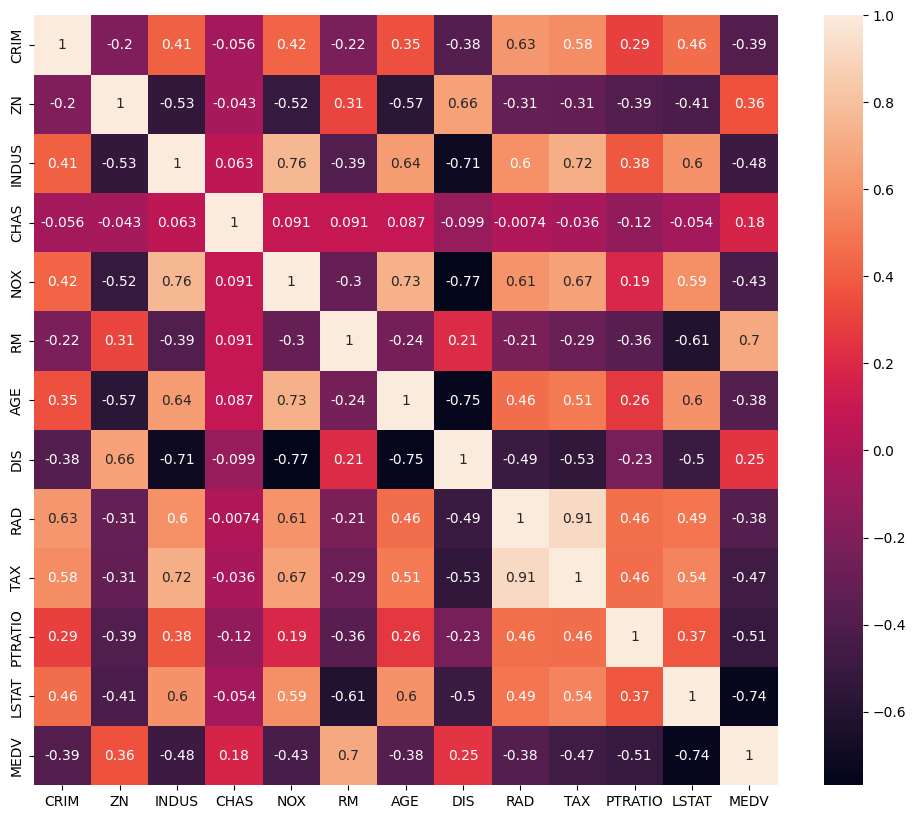

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True);
plt.show()

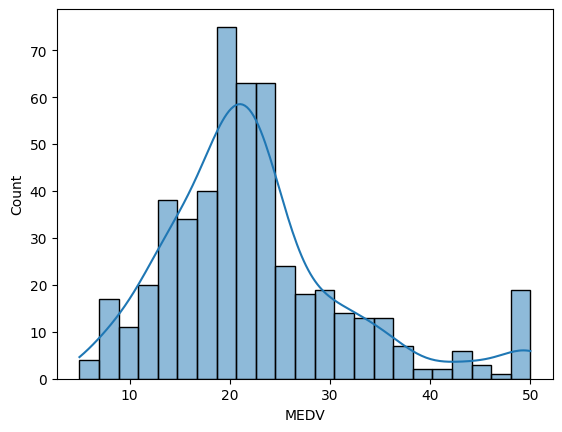

In [8]:
sns.histplot(df["MEDV"], kde=True)
plt.show()

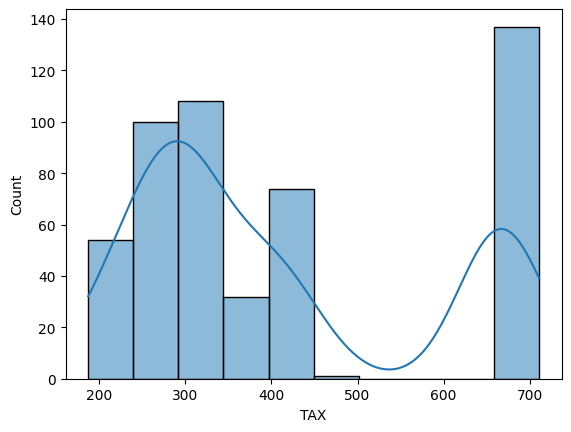

In [9]:
sns.histplot(df["TAX"], kde=True)
plt.show()

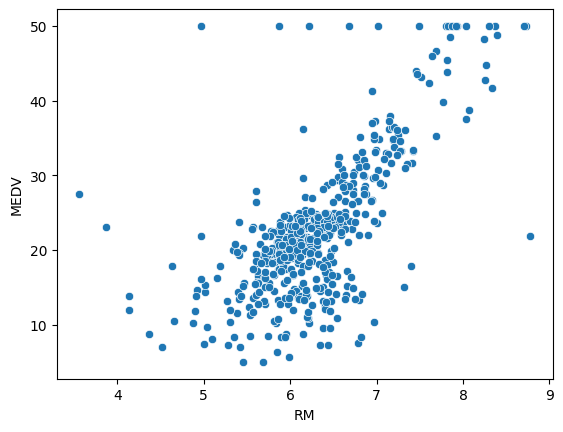

In [10]:
sns.scatterplot(x=df["RM"], y=df["MEDV"])
plt.show()

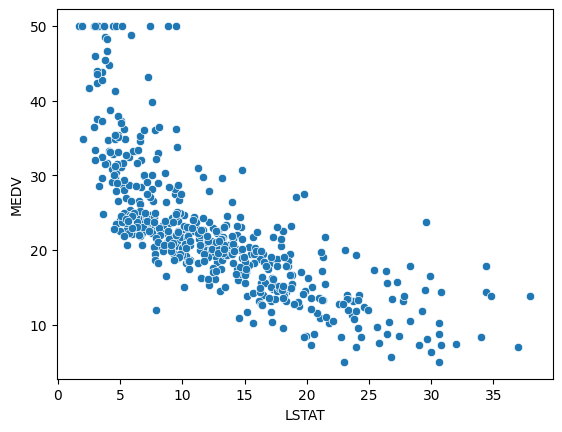

In [11]:
sns.scatterplot(x=df["LSTAT"], y=df["MEDV"])
plt.show()

In [12]:
features = ["CRIM", "ZN", "INDUS", "NOX", "RM", "AGE","DIS", "RAD", "TAX", "PTRATIO", "LSTAT"]

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 1. Ajustas SOLO con train
X_train = scaler.fit_transform(X_train)

# 2. Aplicas al test con el MISMO scaler
X_test = scaler.transform(X_test)


Escalo porque las features están en escalas muy distintas y la regresión lineal es sensible a la escala de las variables, especialmente de cara a la interpretación de coeficientes y a la regularización posterior.

In [14]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
pd.Series(lin_reg.coef_, index=X.columns).sort_values(ascending=False)

RM         3.004420
RAD        2.058898
CHAS       0.787152
ZN         0.712109
INDUS      0.173858
AGE       -0.100500
CRIM      -1.127473
TAX       -1.871317
PTRATIO   -1.991871
NOX       -2.137599
DIS       -3.119459
LSTAT     -3.819016
dtype: float64

In [17]:
y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

print("MAE train: ", metrics.mean_absolute_error(y_train, y_train_pred))
print("RMSE train: ", np.sqrt(metrics.mean_absolute_error(y_train, y_train_pred)))
print("R2 train: ", lin_reg.score(X_train, y_train))

print("\n------------------------------------------------------------\n")


print("MAE test: ", metrics.mean_absolute_error(y_test, y_test_pred))
print("RMSE test: ", np.sqrt(metrics.mean_absolute_error(y_test, y_test_pred)))
print("R2 test: ", lin_reg.score(X_test, y_test))

MAE train:  3.424468775949534
RMSE train:  1.8505320251077888
R2 train:  0.739801993681731

------------------------------------------------------------

MAE test:  3.111377388238187
RMSE test:  1.7639096882318512
R2 test:  0.689396788461476


El modelo explica aprox 70% de la variabilidad del precio.   
Y en cuenato a los errores, se puede apreciar un error realtivo de 12-15%.

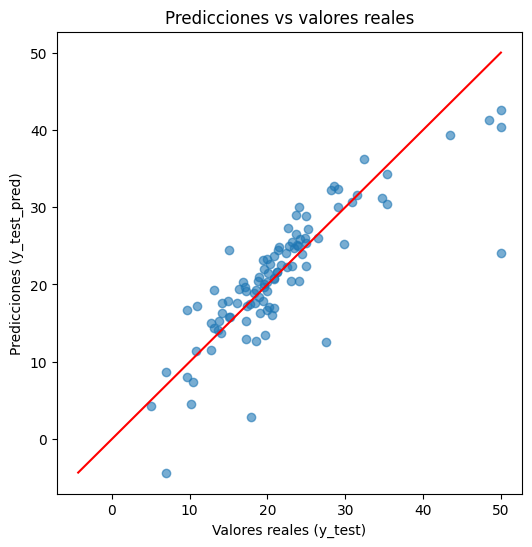

In [20]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6)

min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

# Etiquetas
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_test_pred)")
plt.title("Predicciones vs valores reales")

plt.show()


In [22]:
from sklearn.linear_model import Ridge

ridgeR = Ridge(alpha = 10)
ridgeR.fit(X_train, y_train)

y_train_pred_ridge = ridgeR.predict(X_train)
y_test_pred_ridge = ridgeR.predict(X_test)

print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred_ridge))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_ridge)))
print('R2 train', ridgeR.score(X_train,y_train))

print("\n------------------------------------------------------------\n")

print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred_ridge))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_ridge)))
print('R2 test', ridgeR.score(X_test,y_test))

MAE train 3.39982174128184
RMSE train 4.763839804921926
R2 train 0.7387673478226372

------------------------------------------------------------

MAE test 3.085876006181848
RMSE test 4.805473935934505
R2 test 0.6851031168205155


In [23]:
ridgeR = Ridge(alpha = 5)
ridgeR.fit(X_train, y_train)

y_train_pred_ridge = ridgeR.predict(X_train)
y_test_pred_ridge = ridgeR.predict(X_test)

print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred_ridge))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_ridge)))
print('R2 train', ridgeR.score(X_train,y_train))

print("\n------------------------------------------------------------\n")

print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred_ridge))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_ridge)))
print('R2 test', ridgeR.score(X_test,y_test))

MAE train 3.408676163934927
RMSE train 4.757286463438083
R2 train 0.7394855790533061

------------------------------------------------------------

MAE test 3.0955141263993857
RMSE test 4.789742316477174
R2 test 0.6871614899766328


In [24]:
ridgeR = Ridge(alpha = 15)
ridgeR.fit(X_train, y_train)

y_train_pred_ridge = ridgeR.predict(X_train)
y_test_pred_ridge = ridgeR.predict(X_test)

print('MAE train', metrics.mean_absolute_error(y_train, y_train_pred_ridge))
print('RMSE train', np.sqrt(metrics.mean_squared_error(y_train, y_train_pred_ridge)))
print('R2 train', ridgeR.score(X_train,y_train))

print("\n------------------------------------------------------------\n")

print('MAE test', metrics.mean_absolute_error(y_test, y_test_pred_ridge))
print('RMSE test', np.sqrt(metrics.mean_squared_error(y_test, y_test_pred_ridge)))
print('R2 test', ridgeR.score(X_test,y_test))

MAE train 3.3932229212472023
RMSE train 4.7723186722551345
R2 train 0.7378366162174625

------------------------------------------------------------

MAE test 3.077351363358837
RMSE test 4.819584451279744
R2 test 0.6832511118070187
